In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/global_financial_markets_2000_Now.csv')
df.head(30)

,date,open,high,low,close,volume,symbol,asset_name,asset_type,region
0,2000-01-03,1469.2500,1478.0000,1438.3600,1455.2200,931800000,^GSPC,S&P500,Stock Index,Global
1,2000-01-03,6961.7202,7159.3301,6720.8701,6750.7598,43072500,^GDAXI,DAX,Stock Index,Global
2,2000-01-03,5209.5400,5384.6602,5209.5400,5375.1099,0,^BSESN,SENSEX,Stock Index,Global
3,2000-01-03,0.0098,0.0099,0.0097,0.0098,0,JPYUSD=X,JPY/USD,Currency,Global
4,2000-01-03,17057.6992,17426.1602,17057.6992,17369.6309,0,^HSI,HSI,Stock Index,Global
5,2000-01-03,4186.1899,4192.1899,3989.7100,4131.1499,1510070000,^IXIC,NASDAQ,Stock Index,Global
6,2000-01-04,0.0098,0.0099,0.0097,0.0097,0,JPYUSD=X,JPY/USD,Currency,Global
7,2000-01-04,1368.6930,1407.5179,1361.2140,1406.3710,0,000001.SS,Shanghai,Stock Index,Global
8,2000-01-04,17303.0000,17303.0000,16933.5195,17072.8203,0,^HSI,HSI,Stock Index,Global
9,2000-01-04,18937.4492,19187.6094,18937.4492,19002.8594,0,^N225,Nikkei225,Stock Index,Global


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186524 entries, 0 to 186523
Data columns (total 10 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        186524 non-null  object 
 1   open        186524 non-null  float64
 2   high        186524 non-null  float64
 3   low         186524 non-null  float64
 4   close       186524 non-null  float64
 5   volume      186524 non-null  int64  
 6   symbol      186524 non-null  object 
 7   asset_name  186524 non-null  object 
 8   asset_type  186524 non-null  object 
 9   region      186524 non-null  object 
dtypes: float64(4), int64(1), object(5)
memory usage: 14.2+ MB


In [ ]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])

# Check for missing values
print(df.isnull().sum())

# Handling missing values (e.g., dropping or forward filling)
df = df.fillna(method='ffill')

date          0
open          0
high          0
low           0
close         0
volume        0
symbol        0
asset_name    0
asset_type    0
region        0
dtype: int64


/tmp/ipykernel_4191/1132130570.py:8: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


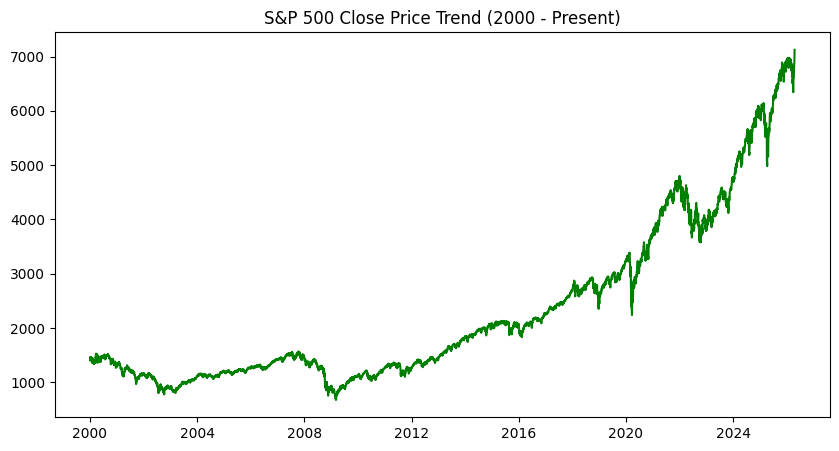

In [ ]:
# S&P 500 Trend Plot
sp500 = df[df['asset_name'] == 'S&P500'].sort_values('date')
plt.figure(figsize=(10, 5))
plt.plot(sp500['date'], sp500['close'], color='green')
plt.title('S&P 500 Close Price Trend (2000 - Present)')
plt.show()

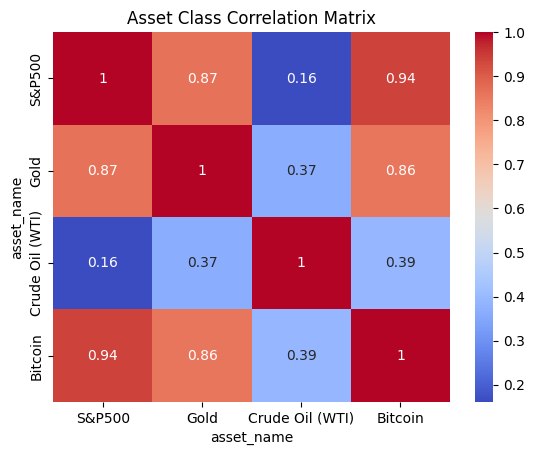

In [ ]:
# Create a pivot table for correlation analysis
pivot_df = df.pivot(index='date', columns='asset_name', values='close')
correlation_matrix = pivot_df[['S&P500', 'Gold', 'Crude Oil (WTI)',
                    'Bitcoin']].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Asset Class Correlation Matrix')
plt.show()

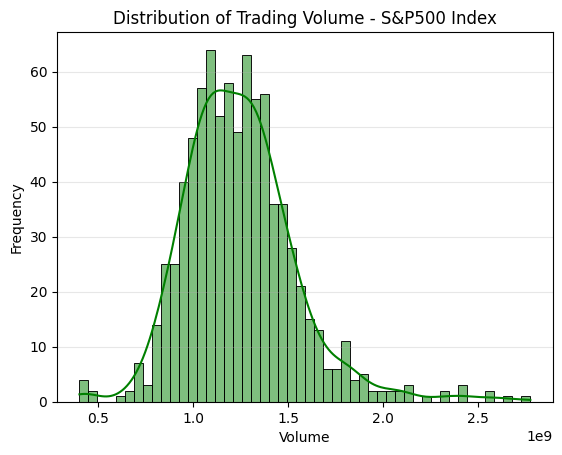

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('global_financial_markets_2000_Now.csv')

# Filter for S&P500
sp500_data = df[df['asset_name'] == 'S&P500']

# Create Distribution Plot
sns.histplot(sp500_data['volume'], bins=50, kde=True, color='Green')
plt.title('Distribution of Trading Volume - S&P500 Index')
plt.xlabel('Volume')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.savefig('volume_distribution_separate.png')